In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.5.1-cp314-cp314-win_amd64.whl.metadata (46 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl (156 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached charset_normalizer-3.5.1-cp314-cp314-win_amd64.whl (204 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)

   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ---- -----------------------------------  1/10 [tqdm]
   -------- -------------------------------  2/10 [pyyaml]
   -------- -------------------------------  2/10 [pyyaml]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/1

c:\Users\1tsth\anaconda3\envs\vscode101\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 117M/117M [00:27<00:00, 4.45MB/s] 

Extracting files...


Path to dataset files: C:\Users\1tsth\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [6]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [12]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [9]:
df.shape

(2443651, 9)

In [10]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')

In [11]:
## Part 1 - Understanding Product Categories

category_frequency = df["category"].value_counts()

category_frequency

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [ ]:
top_5_categories = category_frequency.head(5)

top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

### Top 5 Product Categories

The five most frequently listed product categories are:

1. Sports & Outdoors
2. Beauty
3. Handmade Clothing, Shoes & Accessories
4. Bath & Body
5. Birthday Gifts

Sports & Outdoors has dramatically more listings than the other leading categories, suggesting that the category distribution is highly uneven.

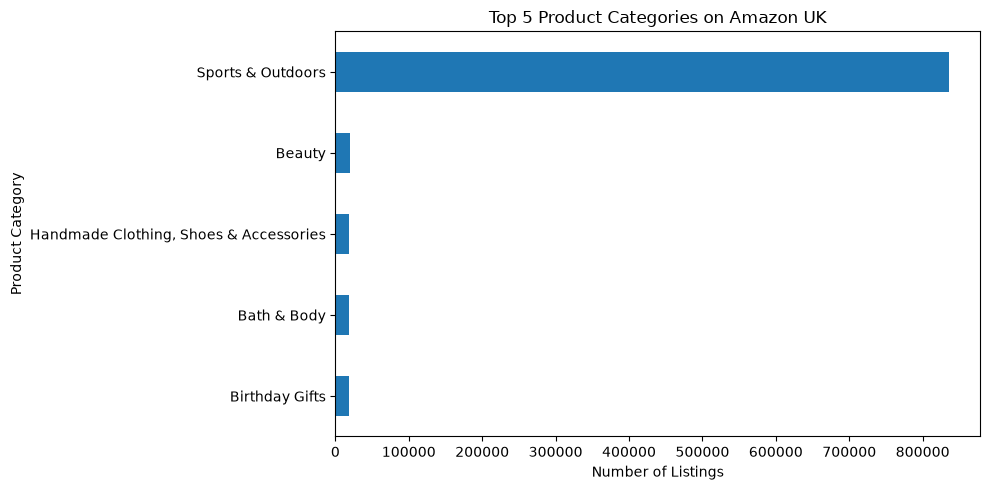

In [14]:
plt.figure(figsize=(10, 5))

top_5_categories.sort_values().plot(kind="barh")

plt.title("Top 5 Product Categories on Amazon UK")
plt.xlabel("Number of Listings")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Conclusion

The product category distribution is highly uneven. Sports & Outdoors dominates the listings by a very large margin, while the other top categories have similar but much lower frequencies. This suggests that Amazon UK product listings are heavily concentrated in one category rather than being evenly distributed across the leading categories.

## Part 2 - Delving into Product Pricing

In [15]:
mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()[0]

print("Mean price:", mean_price)
print("Median price:", median_price)
print("Mode price:", mode_price)

Mean price: 89.24380943923661
Median price: 19.09
Mode price: 9.99


### Price Centrality - Interpretation

The average product price is approximately **£89.24**, while the median price is much lower at **£19.09** and the most common price is **£9.99**.

The mean being much higher than both the median and mode suggests that the price distribution is strongly **right-skewed**. A relatively small number of very expensive products are likely pulling the average upwards.

For a typical Amazon UK product listing, the median of £19.09 may therefore be more representative than the mean.

In [16]:
price_variance = df["price"].var()
price_std = df["price"].std()

price_min = df["price"].min()
price_max = df["price"].max()
price_range = price_max - price_min

q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
price_iqr = q3 - q1

print("Variance:", price_variance)
print("Standard deviation:", price_std)
print("Range:", price_range)
print("IQR:", price_iqr)

Variance: 119445.48532254901
Standard deviation: 345.60886175349873
Range: 100000.0
IQR: 36.0


### Price Dispersion - Interpretation

Product prices show a very large amount of variation.

- The **standard deviation is approximately £345.61**, which is very large compared with the median price of £19.09.
- The **total range is £100,000**, showing that some products are priced dramatically higher than typical products.
- However, the **IQR is only £36**, meaning the middle 50% of product prices are contained within a relatively narrow £36 range.

Together with the mean (£89.24) being much higher than the median (£19.09), this suggests that most products are relatively inexpensive, while a small number of extremely expensive products create a large spread and pull the mean upwards.

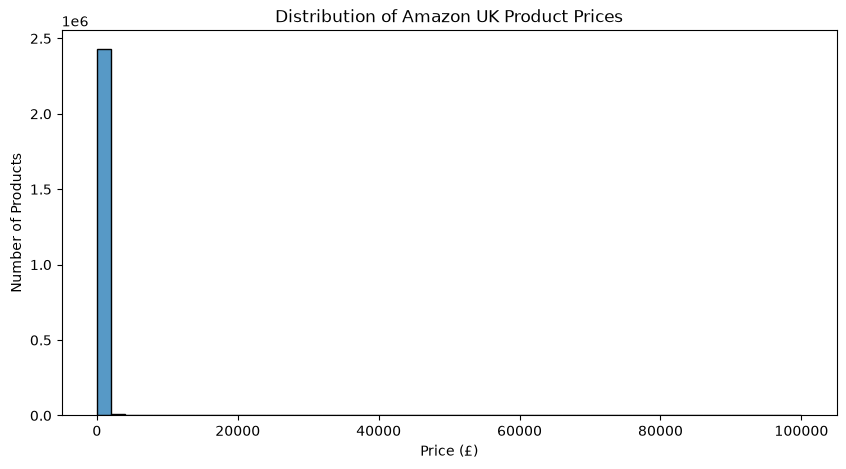

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="price",
    bins=50
)

plt.title("Distribution of Amazon UK Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")

plt.show()

### Histogram Interpretation

The full price histogram is difficult to interpret because a small number of extremely high-priced products stretch the x-axis to approximately £100,000.

As a result, the majority of product prices are compressed into a very small area at the lower end of the chart.

This confirms the strong right-skew suggested by the mean, median and mode. To better understand the typical product-price distribution, the extreme upper values can be excluded from the visualisation while keeping them in the original dataset.

In [18]:
upper_limit = q3 + 1.5 * price_iqr

print("Upper outlier limit:", upper_limit)

Upper outlier limit: 99.99000000000001


Using stadard IQR rule to identify the upper outlier boundary

In [19]:
typical_prices = df[df["price"] <= upper_limit]

temporary filtered dataset just for the chart

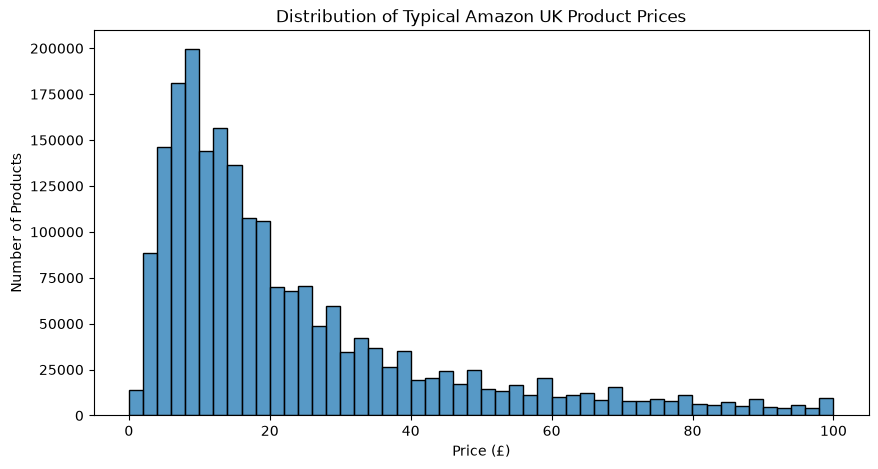

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=typical_prices,
    x="price",
    bins=50
)

plt.title("Distribution of Typical Amazon UK Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")

plt.show()

### Histogram Interpretation

After excluding the extreme upper-price outliers from the visualisation, the underlying distribution becomes much clearer.

Most products are concentrated at the lower end of the price range, with the highest frequencies roughly between **£5 and £20**. As price increases, the number of listed products generally falls.

The distribution still has a long tail to the right, so product prices remain **positively skewed** even after the most extreme values are excluded from the chart.

### Product Pricing Conclusion

Amazon UK product prices are highly right-skewed.

The median price (£19.09) and mode (£9.99) are much lower than the mean price (£89.24), showing that a relatively small number of very expensive products pull the average upwards.

The middle 50% of prices fall within a relatively narrow £36 range, while the overall range extends to £100,000. This indicates substantial price outliers.

For business decision-making, the median is therefore likely to be a more representative measure of a typical product price than the mean.

## Part 3 - Unpacking Product Ratings

### Measures of Centrality

In [21]:
mean_rating = df["stars"].mean()
median_rating = df["stars"].median()
mode_rating = df["stars"].mode()[0]

print("Mean rating:", mean_rating)
print("Median rating:", median_rating)
print("Mode rating:", mode_rating)

Mean rating: 2.152836472966066
Median rating: 0.0
Mode rating: 0.0


unusual set of results so will check if this is also giving a 0 for unrated products

In [22]:
zero_star_products = df[df["stars"] == 0]

print("Products with 0 stars:", len(zero_star_products))
print("0 stars AND 0 reviews:", len(zero_star_products[zero_star_products["reviews"] == 0]))
print("0 stars AND reviews > 0:", len(zero_star_products[zero_star_products["reviews"] > 0]))

Products with 0 stars: 1225641
0 stars AND 0 reviews: 1225641
0 stars AND reviews > 0: 0


In [23]:
df.loc[df["stars"] == 0, ["stars", "reviews"]].head(10)

,stars,reviews
25,0.0,0
90,0.0,0
97,0.0,0
246,0.0,0
254,0.0,0
332,0.0,0
372,0.0,0
377,0.0,0
434,0.0,0
445,0.0,0


### Rating Data Preparation

A large number of products have a star value of `0.0`. Checking these records showed that every product with zero stars also has zero reviews.

This indicates that `0.0` represents products that have not yet received a customer rating rather than genuine zero-star ratings.

Therefore, products with `stars == 0` are excluded from the customer rating analysis. The original dataset is retained unchanged, and a filtered dataset containing only rated products is used for this section.

In [24]:
rated_products = df[df["stars"] > 0]

In [25]:
mean_rating = rated_products["stars"].mean()
median_rating = rated_products["stars"].median()
mode_rating = rated_products["stars"].mode()[0]

print("Mean rating:", mean_rating)
print("Median rating:", median_rating)
print("Mode rating:", mode_rating)

Mean rating: 4.319160762226911
Median rating: 4.4
Mode rating: 4.5


### Rating Centrality - Interpretation

Among products that have received customer ratings, ratings are generally high.

- The **mean rating is approximately 4.32 stars**.
- The **median is 4.4 stars**.
- The **most common rating is 4.5 stars**.

These values are close together and concentrated above 4 stars, indicating generally positive customer feedback.

The mean being slightly lower than the median and mode may suggest some lower ratings are pulling the average down, although skewness will be calculated later to confirm the shape of the distribution.

In [26]:
rating_variance = rated_products["stars"].var()
rating_std = rated_products["stars"].std()

q1_rating = rated_products["stars"].quantile(0.25)
q3_rating = rated_products["stars"].quantile(0.75)
rating_iqr = q3_rating - q1_rating

print("Variance:", rating_variance)
print("Standard deviation:", rating_std)
print("IQR:", rating_iqr)

Variance: 0.3083433752387284
Standard deviation: 0.5552867504620729
IQR: 0.5


### Rating Dispersion - Interpretation

Customer ratings show relatively low variation.

- The **standard deviation is approximately 0.56 stars**, so ratings typically sit fairly close to the mean of 4.32.
- The **IQR is 0.5 stars**, meaning the middle 50% of ratings are concentrated within a narrow half-star range.
- The **variance is approximately 0.31**, also indicating limited spread.

Overall, rated products tend to receive consistently high scores rather than being spread widely across the full 1-to-5-star scale.

In [27]:
rating_skew = rated_products["stars"].skew()
rating_kurtosis = rated_products["stars"].kurt()

print("Skewness:", rating_skew)
print("Kurtosis:", rating_kurtosis)

Skewness: -2.379568112212799
Kurtosis: 9.78193769066435


### Rating Distribution Shape - Interpretation

The ratings distribution is **strongly negatively (left) skewed**, with a skewness of approximately **-2.38**.

This means most rated products are concentrated at the higher end of the rating scale, while a smaller number of poorly rated products create a long tail towards lower ratings.

The kurtosis is approximately **9.78**, which is much higher than 0. This indicates a distribution with a strong peak and heavy tails, meaning ratings are highly concentrated around common high values but there are also some unusually low ratings.

Overall, customers tend to rate products highly, with relatively few low-rated products.

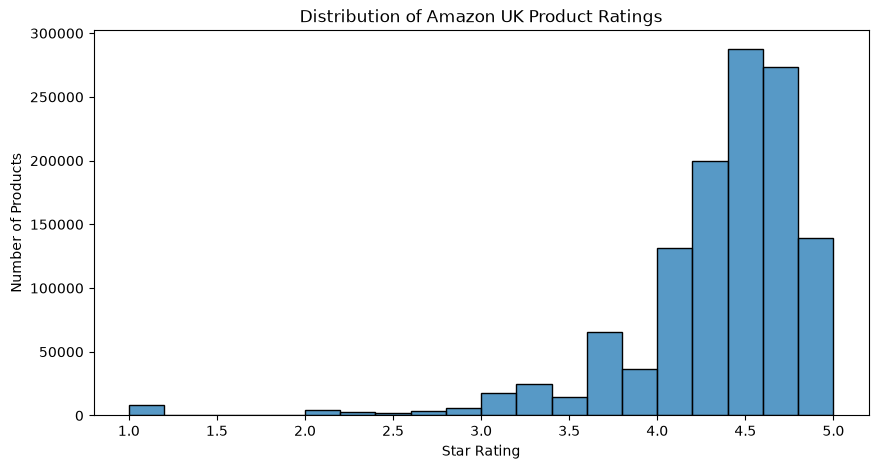

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=rated_products,
    x="stars",
    bins=20
)

plt.title("Distribution of Amazon UK Product Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Products")

plt.show()

### Ratings Section - Final Summary

To make the ratings analysis meaningful, products with `stars == 0` were excluded because every zero-star product also had zero reviews, indicating that these listings were unrated rather than genuinely rated zero stars.

Among rated products, customer feedback is generally very positive. The **mean rating is 4.32**, the **median is 4.4**, and the **mode is 4.5**, showing that ratings are concentrated at the higher end of the 5-star scale.

Variation is relatively low, with a **variance of 0.31**, a **standard deviation of 0.56**, and an **IQR of 0.5**, indicating that most ratings are clustered fairly closely together.

The distribution is **strongly negatively skewed** (`-2.38`), meaning most ratings are high while a smaller number of low ratings create a long left tail. The **high kurtosis of 9.78** indicates a sharply concentrated distribution with heavier tails than a normal distribution.

Overall, rated Amazon UK products tend to receive consistently high customer ratings, while unrated products form a separate group that should not be treated as poor ratings.